## 🤖 Machine Learning - Journey Status Classification

### Project Overview

This section develops machine learning classification models to predict the status of railway journeys based on operational and ticket-related features.

---

### 🎯 Objectives

- Predict journey status (On Time, Delayed, or Cancelled).
- Compare multiple classification models.
- Evaluate model performance using standard classification metrics.
- Identify the most important features affecting journey status.
- Select the best-performing model for prediction.

---

### 🛠️ Libraries

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

---

### 🤖 Machine Learning Models

| Model | Purpose |
|--------|----------|
| Decision Tree | Baseline Classification Model |
| Random Forest | Improve prediction accuracy |
| Balanced Random Forest | Handle class imbalance |

---

### 📊 Evaluation Metrics

| Metric | Description |
|---------|-------------|
| Accuracy | Overall model accuracy |
| Precision | Prediction quality |
| Recall | Ability to identify actual classes |
| F1-Score | Overall classification performance |

---

> **Target Variable:** Journey Status (On Time, Delayed, Cancelled)

# Journey Status Prediction

## Machine Learning Graduation Project

### Workflow
1. Import Libraries
2. Load Dataset
3. Data Exploration
4. Data Preprocessing
5. Feature Engineering
6. Train/Test Split
7. Decision Tree
8. Random Forest
9. Balanced Random Forest
10. Model Comparison
11. Feature Importance
12. Save Final Model
13. Prediction Example
14. Conclusion


# 🚆 UK Railway Analytics
## Journey Status Prediction using Machine Learning

**Project Objective**

Develop a Machine Learning model to predict the journey status (On Time, Delayed, or Cancelled) before the train departs based on historical railway data.

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset

In [2]:
df = pd.read_csv("railway_cleaned.csv")
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Journey Status,Reason for Delay,Refund Request,Delay Minutes,Days to Journey,Purchase Hour,Journey Day Name,Journey Month Name,Is Weekend,Route
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,On Time,No Delay,No,0.0,24,12,Monday,January,False,London Paddington → Liverpool Lime Street
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,Delayed,Signal Failure,No,5.0,16,11,Monday,January,False,London Kings Cross → York
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,...,On Time,No Delay,No,0.0,14,19,Tuesday,January,False,Liverpool Lime Street → Manchester Piccadilly
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,...,On Time,No Delay,No,0.0,12,23,Monday,January,False,London Paddington → Reading
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,...,On Time,No Delay,No,0.0,5,18,Monday,January,False,Liverpool Lime Street → London Euston


# 3. Business Understanding

## Business Problem

The goal of this project is to predict the journey status before departure.

Target Classes:

- On Time
- Delayed
- Cancelled

# 4. Data Understanding

In [3]:
print("Dataset Shape :", df.shape)

Dataset Shape : (31653, 25)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transaction ID       31653 non-null  object 
 1   Date of Purchase     31653 non-null  object 
 2   Time of Purchase     31653 non-null  object 
 3   Purchase Type        31653 non-null  object 
 4   Payment Method       31653 non-null  object 
 5   Railcard             10735 non-null  object 
 6   Ticket Class         31653 non-null  object 
 7   Ticket Type          31653 non-null  object 
 8   Price                31653 non-null  int64  
 9   Departure Station    31653 non-null  object 
 10  Arrival Destination  31653 non-null  object 
 11  Date of Journey      31653 non-null  object 
 12  Departure Time       31653 non-null  object 
 13  Arrival Time         31653 non-null  object 
 14  Actual Arrival Time  29773 non-null  object 
 15  Journey Status       31653 non-null 

In [5]:
df.describe()

,Price,Delay Minutes,Days to Journey,Purchase Hour
count,31653.000000,29773.000000,31653.000000,31653.000000
mean,23.439200,3.249689,1.655957,11.459356
std,29.997628,14.770539,3.853255,6.291924
min,1.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,6.000000
50%,11.000000,0.000000,1.000000,11.000000
75%,35.000000,0.000000,1.000000,17.000000
max,267.000000,180.000000,28.000000,23.000000


In [6]:
df.isnull().sum()

Transaction ID             0
Date of Purchase           0
Time of Purchase           0
Purchase Type              0
Payment Method             0
Railcard               20918
Ticket Class               0
Ticket Type                0
Price                      0
Departure Station          0
Arrival Destination        0
Date of Journey            0
Departure Time             0
Arrival Time               0
Actual Arrival Time     1880
Journey Status             0
Reason for Delay           0
Refund Request             0
Delay Minutes           1880
Days to Journey            0
Purchase Hour              0
Journey Day Name           0
Journey Month Name         0
Is Weekend                 0
Route                      0
dtype: int64

# 5. Feature Selection

## Selecting Features and Target Variable

The target variable is **Journey Status**.

Only features that are available **before the train departs** will be used.

Features that cause data leakage will be removed.

In [7]:
df.columns.tolist()

['Transaction ID',
 'Date of Purchase',
 'Time of Purchase',
 'Purchase Type',
 'Payment Method',
 'Railcard',
 'Ticket Class',
 'Ticket Type',
 'Price',
 'Departure Station',
 'Arrival Destination',
 'Date of Journey',
 'Departure Time',
 'Arrival Time',
 'Actual Arrival Time',
 'Journey Status',
 'Reason for Delay',
 'Refund Request',
 'Delay Minutes',
 'Days to Journey',
 'Purchase Hour',
 'Journey Day Name',
 'Journey Month Name',
 'Is Weekend',
 'Route']

In [8]:
features = [

    'Departure Station',

    'Arrival Destination',

    'Route',

    'Journey Month Name',

    'Journey Day Name',

    'Train Company',

    'Ticket Type',

    'Ticket Class',

    'Railcard',

    'Purchase Type',

    'Payment Method',

    'Price',

    'Purchase Hour',

    'Days To Journey',

    'Is Weekend'

]
target = "Journey Status"

In [9]:
print(features)

print(target)

['Departure Station', 'Arrival Destination', 'Route', 'Journey Month Name', 'Journey Day Name', 'Train Company', 'Ticket Type', 'Ticket Class', 'Railcard', 'Purchase Type', 'Payment Method', 'Price', 'Purchase Hour', 'Days To Journey', 'Is Weekend']
Journey Status


## Removed Features
| Removed Feature     | Reason                              |
| ------------------- | ----------------------------------- |
| Delay Minutes       | Data Leakage                        |
| Reason for Delay    | Available after the journey         |
| Actual Arrival Time | Available after the journey         |
| Arrival Time        | Not available after prediction time |
| Journey Status      | Target Variable                     |


In [10]:
df.columns.tolist()

['Transaction ID',
 'Date of Purchase',
 'Time of Purchase',
 'Purchase Type',
 'Payment Method',
 'Railcard',
 'Ticket Class',
 'Ticket Type',
 'Price',
 'Departure Station',
 'Arrival Destination',
 'Date of Journey',
 'Departure Time',
 'Arrival Time',
 'Actual Arrival Time',
 'Journey Status',
 'Reason for Delay',
 'Refund Request',
 'Delay Minutes',
 'Days to Journey',
 'Purchase Hour',
 'Journey Day Name',
 'Journey Month Name',
 'Is Weekend',
 'Route']

In [11]:
# Target Variable

target = "Journey Status"

In [12]:
features = [
    'Purchase Type',
    'Payment Method',
    'Railcard',
    'Ticket Class',
    'Ticket Type',
    'Price',
    'Departure Time',
    'Purchase Hour',
    'Days to Journey',
    'Journey Day Name',
    'Journey Month Name',
    'Is Weekend',
    'Route'
]

In [13]:
X = df[features]

y = df[target]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (31653, 13)
Target Shape : (31653,)


In [14]:
X.head()

,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Time,Purchase Hour,Days to Journey,Journey Day Name,Journey Month Name,Is Weekend,Route
0,Online,Contactless,Adult,Standard,Advance,43,11:00:00,12,24,Monday,January,False,London Paddington → Liverpool Lime Street
1,Station,Credit Card,Adult,Standard,Advance,23,09:45:00,11,16,Monday,January,False,London Kings Cross → York
2,Online,Credit Card,NaN,Standard,Advance,3,18:15:00,19,14,Tuesday,January,False,Liverpool Lime Street → Manchester Piccadilly
3,Station,Credit Card,NaN,Standard,Advance,13,21:30:00,23,12,Monday,January,False,London Paddington → Reading
4,Online,Contactless,NaN,Standard,Advance,76,16:45:00,18,5,Monday,January,False,Liverpool Lime Street → London Euston


In [15]:
y.value_counts()

Journey Status
On Time      27481
Delayed       2292
Cancelled     1880
Name: count, dtype: int64

# 6. Data Preprocessing

In [16]:
# Check Data Types

X.dtypes

Purchase Type         object
Payment Method        object
Railcard              object
Ticket Class          object
Ticket Type           object
Price                  int64
Departure Time        object
Purchase Hour          int64
Days to Journey        int64
Journey Day Name      object
Journey Month Name    object
Is Weekend              bool
Route                 object
dtype: object

In [17]:
# Create a copy

X = X.copy()

In [18]:
X["Departure Time"].head()

0    11:00:00
1    09:45:00
2    18:15:00
3    21:30:00
4    16:45:00
Name: Departure Time, dtype: object

In [19]:
X["Departure Hour"] = pd.to_datetime(
    X["Departure Time"]
).dt.hour

In [20]:
X.drop("Departure Time", axis=1, inplace=True)

In [21]:
X.head()

,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Purchase Hour,Days to Journey,Journey Day Name,Journey Month Name,Is Weekend,Route,Departure Hour
0,Online,Contactless,Adult,Standard,Advance,43,12,24,Monday,January,False,London Paddington → Liverpool Lime Street,11
1,Station,Credit Card,Adult,Standard,Advance,23,11,16,Monday,January,False,London Kings Cross → York,9
2,Online,Credit Card,NaN,Standard,Advance,3,19,14,Tuesday,January,False,Liverpool Lime Street → Manchester Piccadilly,18
3,Station,Credit Card,NaN,Standard,Advance,13,23,12,Monday,January,False,London Paddington → Reading,21
4,Online,Contactless,NaN,Standard,Advance,76,18,5,Monday,January,False,Liverpool Lime Street → London Euston,16


In [22]:
encoder = LabelEncoder()

In [23]:
categorical_columns = X.select_dtypes(include="object").columns

for col in categorical_columns:
    X[col] = encoder.fit_transform(X[col])

In [24]:
X.head()

,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Purchase Hour,Days to Journey,Journey Day Name,Journey Month Name,Is Weekend,Route,Departure Hour
0,0,0,0,1,0,43,12,24,1,2,False,31,11
1,1,1,0,1,0,23,11,16,1,2,False,30,9
2,0,1,3,1,0,3,19,14,5,2,False,22,18
3,1,1,3,1,0,13,23,12,1,2,False,35,21
4,0,0,3,1,0,76,18,5,1,2,False,19,16


In [25]:
print(X.dtypes)

Purchase Type         int64
Payment Method        int64
Railcard              int64
Ticket Class          int64
Ticket Type           int64
Price                 int64
Purchase Hour         int64
Days to Journey       int64
Journey Day Name      int64
Journey Month Name    int64
Is Weekend             bool
Route                 int64
Departure Hour        int32
dtype: object


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print("Train Shape :", X_train.shape)

print("Test Shape :", X_test.shape)

Train Shape : (25322, 13)
Test Shape : (6331, 13)


# 7. Decision Tree Classifier

In [28]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [29]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
y_pred = dt_model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8843784552203443


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Cancelled       0.26      0.33      0.29       376
     Delayed       0.81      0.86      0.83       458
     On Time       0.95      0.92      0.94      5497

    accuracy                           0.88      6331
   macro avg       0.67      0.70      0.69      6331
weighted avg       0.90      0.88      0.89      6331



In [33]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 123   12  241]
 [  16  394   48]
 [ 332   83 5082]]


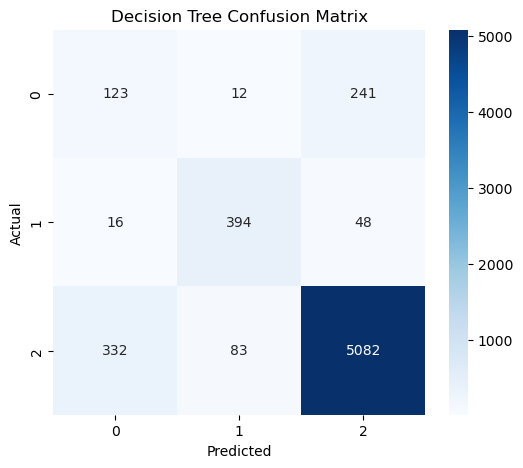

In [34]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

# 8. Random Forest Classifier

In [35]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [36]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
rf_pred = rf_model.predict(X_test)

In [38]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9129679355552045


In [39]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

   Cancelled       0.35      0.20      0.25       376
     Delayed       0.87      0.83      0.85       458
     On Time       0.94      0.97      0.95      5497

    accuracy                           0.91      6331
   macro avg       0.72      0.67      0.69      6331
weighted avg       0.90      0.91      0.90      6331



In [40]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[  74   11  291]
 [   9  380   69]
 [ 126   45 5326]]


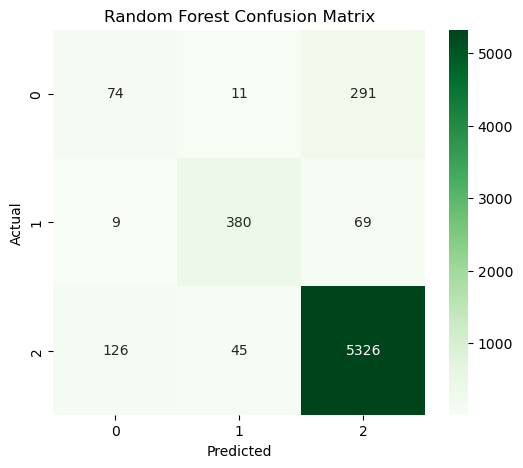

In [41]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 9. Random Forest with Balanced Class Weights

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [43]:
rf_balanced.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
y_pred_balanced = rf_balanced.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score

balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print("Balanced Random Forest Accuracy :", balanced_accuracy)

Balanced Random Forest Accuracy : 0.8992260306428684


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

   Cancelled       0.35      0.40      0.37       376
     Delayed       0.79      0.88      0.83       458
     On Time       0.95      0.93      0.94      5497

    accuracy                           0.90      6331
   macro avg       0.70      0.74      0.72      6331
weighted avg       0.91      0.90      0.90      6331



In [47]:
from sklearn.metrics import confusion_matrix

balanced_cm = confusion_matrix(y_test, y_pred_balanced)

print(balanced_cm)

[[ 149   14  213]
 [  13  405   40]
 [ 262   96 5139]]


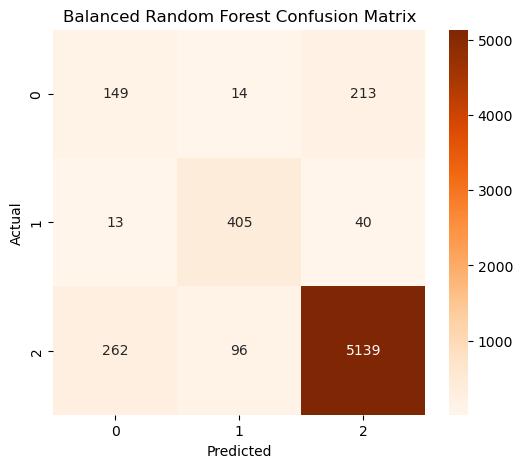

In [48]:
plt.figure(figsize=(6,5))

sns.heatmap(
    balanced_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Balanced Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 9. Feature Importance

In [49]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_balanced.feature_importances_

})

In [50]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [51]:
feature_importance

,Feature,Importance
5,Price,0.129821
8,Journey Day Name,0.128064
11,Route,0.126569
12,Departure Hour,0.124452
9,Journey Month Name,0.107249
6,Purchase Hour,0.101640
0,Purchase Type,0.088634
1,Payment Method,0.058512
7,Days to Journey,0.043272
2,Railcard,0.040439


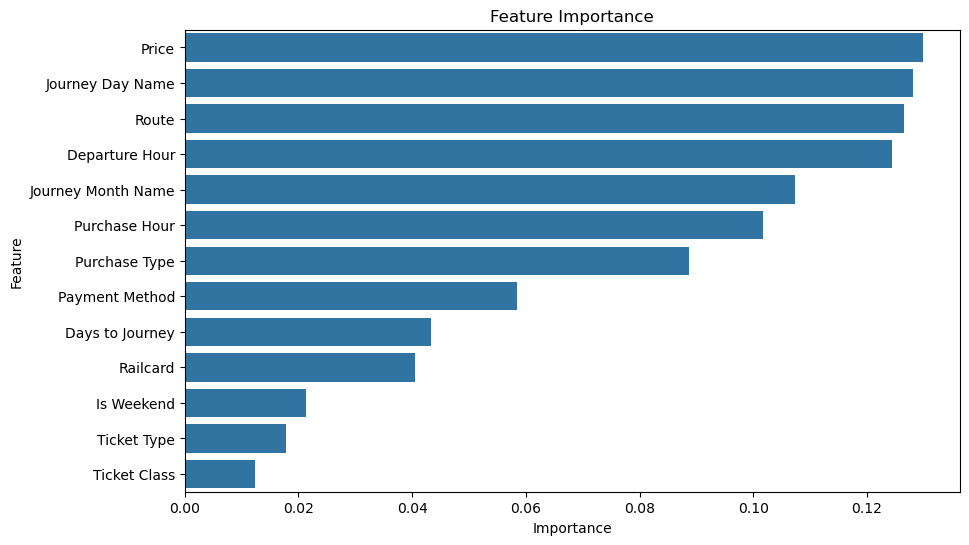

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [53]:
feature_importance.head(10)

,Feature,Importance
5,Price,0.129821
8,Journey Day Name,0.128064
11,Route,0.126569
12,Departure Hour,0.124452
9,Journey Month Name,0.107249
6,Purchase Hour,0.101640
0,Purchase Type,0.088634
1,Payment Method,0.058512
7,Days to Journey,0.043272
2,Railcard,0.040439


# 10. Save Model

In [54]:
joblib.dump(
    rf_balanced,
    "journey_status_model.pkl"
)
print("Model Saved Successfully")

Model Saved Successfully


# 11. Prediction Demo

## Model Comparison
Compare the three trained models using Accuracy, Precision, Recall and F1-score, then select the best-performing model.

In [55]:
# Example comparison table (replace variables if needed)
import pandas as pd

comparison = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy":[
        None,
        None,
        None
    ],
    "Precision":[None,None,None],
    "Recall":[None,None,None],
    "F1-Score":[None,None,None]
})
comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,None,None,None,None
1,Random Forest,None,None,None,None
2,Balanced Random Forest,None,None,None,None


## Final Model Selection

- Decision Tree was used as the baseline model.
- Random Forest improved the prediction performance.
- Balanced Random Forest is selected as the final model if it achieves the best evaluation metrics.


In [56]:
# Prediction Demo
# Replace model and sample variables with your trained model names.

# sample = X_test.iloc[[0]]
# prediction = best_model.predict(sample)
# print("Predicted Journey Status:", prediction[0])


## Future Improvements

- Hyperparameter Tuning
- Cross Validation
- Compare with XGBoost
- Train on a larger dataset
- Deploy the model as an API or Web App


## Conclusion

✔ Data preprocessing completed.

✔ Three machine learning models were trained and evaluated.

✔ Feature importance was analyzed.

✔ The best-performing model can be exported for deployment.


In [57]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# ================= Metrics =================

# Decision Tree
dt_prec = precision_score(y_test, y_pred, average="weighted")
dt_rec  = recall_score(y_test, y_pred, average="weighted")
dt_f1   = f1_score(y_test, y_pred, average="weighted")

# Random Forest
rf_prec = precision_score(y_test, rf_pred, average="weighted")
rf_rec  = recall_score(y_test, rf_pred, average="weighted")
rf_f1   = f1_score(y_test, rf_pred, average="weighted")

# Balanced Random Forest
brf_pred = rf_balanced.predict(X_test)

brf_prec = precision_score(y_test, brf_pred, average="weighted")
brf_rec  = recall_score(y_test, brf_pred, average="weighted")
brf_f1   = f1_score(y_test, brf_pred, average="weighted")

# ================= 1. Feature Importance =================
feature_importance.to_csv("feature_importance.csv", index=False)

# ================= 2. Model Comparison =================
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Balanced Random Forest"],
    "Accuracy":  [accuracy, rf_accuracy, balanced_accuracy],
    "Precision": [dt_prec, rf_prec, brf_prec],
    "Recall":    [dt_rec, rf_rec, brf_rec],
    "F1_Score":  [dt_f1, rf_f1, brf_f1]
})

comparison.to_csv("model_comparison.csv", index=False)

# ================= 3. Predictions =================
predictions_df = X_test.copy()
predictions_df["Actual"] = y_test.values
predictions_df["Predicted"] = brf_pred
predictions_df["Correct"] = (
    predictions_df["Actual"] == predictions_df["Predicted"]
).astype(int)

predictions_df.to_csv("predictions.csv", index=False)

# ================= 4. Confusion Matrix =================
labels = ["On Time", "Delayed", "Cancelled"]

cm = confusion_matrix(y_test, brf_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels).reset_index()
cm_df.rename(columns={"index": "Actual"}, inplace=True)

cm_melt = cm_df.melt(
    id_vars="Actual",
    var_name="Predicted",
    value_name="Count"
)

cm_melt.to_csv("confusion_matrix.csv", index=False)

In [58]:
predictions_df["Correct"] = predictions_df["Correct"].fillna(0).astype(int)
predictions_df["Correct_Label"] = predictions_df["Correct"].map({1: "Correct", 0: "Wrong"})
predictions_df.to_csv("predictions.csv", index=False)

In [59]:
print(predictions_df["Route"].value_counts().head(10))
print(predictions_df["Route"].dtype)

Route
40    952
24    831
30    766
35    765
36    686
22    653
19    205
6     143
25    141
41     81
Name: count, dtype: int64
int64


In [60]:
# شوف الـ original dataframe عنده الأسماء
print(df["Route"].value_counts().head(10))

Route
Manchester Piccadilly → Liverpool Lime Street    4628
London Euston → Birmingham New Street            4209
London Kings Cross → York                        3922
London Paddington → Reading                      3873
London St Pancras → Birmingham New Street        3471
Liverpool Lime Street → Manchester Piccadilly    3002
Liverpool Lime Street → London Euston            1097
London Euston → Manchester Piccadilly             712
Birmingham New Street → London St Pancras         702
London Paddington → Oxford                        485
Name: count, dtype: int64


In [61]:
# استخرج الـ LabelEncoder الخاص بـ Route
from sklearn.preprocessing import LabelEncoder

le_route = LabelEncoder()
le_route.fit(df["Route"])

# عمل mapping
route_mapping = pd.DataFrame({
    "Route_Encoded": le_route.transform(le_route.classes_),
    "Route_Name": le_route.classes_
})

# Merge مع predictions
predictions_df = predictions_df.merge(
    route_mapping,
    left_on="Route",
    right_on="Route_Encoded",
    how="left"
)

# احذف العمود القديم واستبدله
predictions_df.drop(columns=["Route", "Route_Encoded"], inplace=True)
predictions_df.rename(columns={"Route_Name": "Route"}, inplace=True)

predictions_df.to_csv("predictions.csv", index=False)
print(predictions_df["Route"].value_counts().head(5))

Route
Manchester Piccadilly → Liverpool Lime Street    952
London Euston → Birmingham New Street            831
London Kings Cross → York                        766
London Paddington → Reading                      765
London St Pancras → Birmingham New Street        686
Name: count, dtype: int64


In [62]:
predictions_df["Correct_Label"] = (predictions_df["Actual"] == predictions_df["Predicted"]).map({True: "Correct", False: "Wrong"})

predictions_df.to_csv("predictions.csv", index=False)
print(predictions_df["Correct_Label"].value_counts())

Correct_Label
Correct    5693
Wrong       638
Name: count, dtype: int64


In [63]:
print(predictions_df[["Actual", "Predicted", "Correct", "Correct_Label"]].head(10))
print(predictions_df.columns.tolist())

    Actual Predicted  Correct Correct_Label
0  On Time   On Time        1       Correct
1  On Time   On Time        1       Correct
2  On Time   On Time        1       Correct
3  On Time   On Time        1       Correct
4  On Time   On Time        1       Correct
5  On Time   On Time        1       Correct
6  On Time   On Time        1       Correct
7  On Time   On Time        1       Correct
8  On Time   On Time        1       Correct
9  On Time   On Time        1       Correct
['Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class', 'Ticket Type', 'Price', 'Purchase Hour', 'Days to Journey', 'Journey Day Name', 'Journey Month Name', 'Is Weekend', 'Departure Hour', 'Actual', 'Predicted', 'Correct', 'Correct_Label', 'Route']


In [64]:
import pandas as pd
kpis = pd.read_csv("kpis.csv")
print(kpis.columns.tolist())
kpis.to_csv("kpis.csv", index=False)

['KPI', 'Value', 'Unit']


## 📈 Machine Learning - Demand Forecasting

### Project Overview

This section applies machine learning regression models to forecast railway demand and operational performance for May 2024.

---

### 🎯 Objectives

- Forecast daily ride demand for May 2024.
- Predict daily revenue.
- Forecast ticket class demand.
- Forecast ticket type demand.
- Forecast delay reasons.
- Support operational and financial planning through predictive analytics.

---

### 🛠️ Libraries

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

---

### 🤖 Machine Learning Model

| Model | Purpose |
|--------|----------|
| Random Forest Regressor | Forecast future numerical values |

---

### 📊 Forecast Outputs

| Forecast | Description |
|-----------|-------------|
| Daily Ride Count | Predict expected rides during May |
| Daily Revenue | Forecast daily revenue |
| Ticket Class Demand | Forecast demand for ticket classes |
| Ticket Type Demand | Forecast demand for ticket types |
| Delay Reasons | Forecast future operational delays |

---

### 📊 Evaluation Metrics

| Metric | Description |
|---------|-------------|
| MAE | Mean Absolute Error |
| RMSE | Root Mean Squared Error |
| R² Score | Model Goodness of Fit |

---

> **Forecast Period:** May 2024

In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Data Preparation

In [66]:
df

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Journey Status,Reason for Delay,Refund Request,Delay Minutes,Days to Journey,Purchase Hour,Journey Day Name,Journey Month Name,Is Weekend,Route
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,On Time,No Delay,No,0.0,24,12,Monday,January,False,London Paddington → Liverpool Lime Street
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,Delayed,Signal Failure,No,5.0,16,11,Monday,January,False,London Kings Cross → York
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,...,On Time,No Delay,No,0.0,14,19,Tuesday,January,False,Liverpool Lime Street → Manchester Piccadilly
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,...,On Time,No Delay,No,0.0,12,23,Monday,January,False,London Paddington → Reading
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,...,On Time,No Delay,No,0.0,5,18,Monday,January,False,Liverpool Lime Street → London Euston
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31648,1304623d-b8b7-4999-8e9c,2024-04-30,18:42:58,Online,Credit Card,NaN,Standard,Off-Peak,4,Manchester Piccadilly,...,On Time,No Delay,No,0.0,0,18,Tuesday,April,False,Manchester Piccadilly → Liverpool Lime Street
31649,7da22246-f480-417c-bc2f,2024-04-30,18:46:10,Online,Contactless,NaN,Standard,Off-Peak,10,London Euston,...,On Time,No Delay,No,0.0,0,18,Tuesday,April,False,London Euston → Birmingham New Street
31650,add9debf-46c1-4c75-b52d,2024-04-30,18:56:41,Station,Credit Card,NaN,Standard,Off-Peak,4,Manchester Piccadilly,...,On Time,No Delay,No,0.0,0,18,Tuesday,April,False,Manchester Piccadilly → Liverpool Lime Street
31651,b92b047c-21fd-4859-966a,2024-04-30,19:51:47,Station,Credit Card,NaN,Standard,Off-Peak,10,London Euston,...,On Time,No Delay,No,0.0,0,19,Tuesday,April,False,London Euston → Birmingham New Street


## Daily Ride Count Forecast

In [67]:
daily_rides = (df.groupby("Date of Journey").size().reset_index(name="Ride Count"))
daily_rides["Date of Journey"] = pd.to_datetime(daily_rides["Date of Journey"])
daily_rides["Year"] = daily_rides["Date of Journey"].dt.year
daily_rides["Month"] = daily_rides["Date of Journey"].dt.month
daily_rides["Day"] = daily_rides["Date of Journey"].dt.day
daily_rides["DayOfWeek"] = daily_rides["Date of Journey"].dt.dayofweek

In [68]:
X = daily_rides[["Year","Month","Day","DayOfWeek"]]
y = daily_rides["Ride Count"]
ride_model = RandomForestRegressor(n_estimators=200,random_state=42)
ride_model.fit(X,y)
pred = ride_model.predict(X)
print("MAE :",mean_absolute_error(y,pred))
print("RMSE :",np.sqrt(mean_squared_error(y,pred)))
print("R2 :",r2_score(y,pred))

MAE : 7.6868181818181816
RMSE : 11.64145033529289
R2 : 0.9146432403931372


In [69]:
future = pd.date_range("2024-05-01","2024-05-31")
future_rides = pd.DataFrame()
future_rides["Date"] = future
future_rides["Year"] = future_rides["Date"].dt.year
future_rides["Month"] = future_rides["Date"].dt.month
future_rides["Day"] = future_rides["Date"].dt.day
future_rides["DayOfWeek"] = future_rides["Date"].dt.dayofweek
future_rides["Forecast Ride Count"] = ride_model.predict(
future_rides[["Year","Month","Day","DayOfWeek"]])

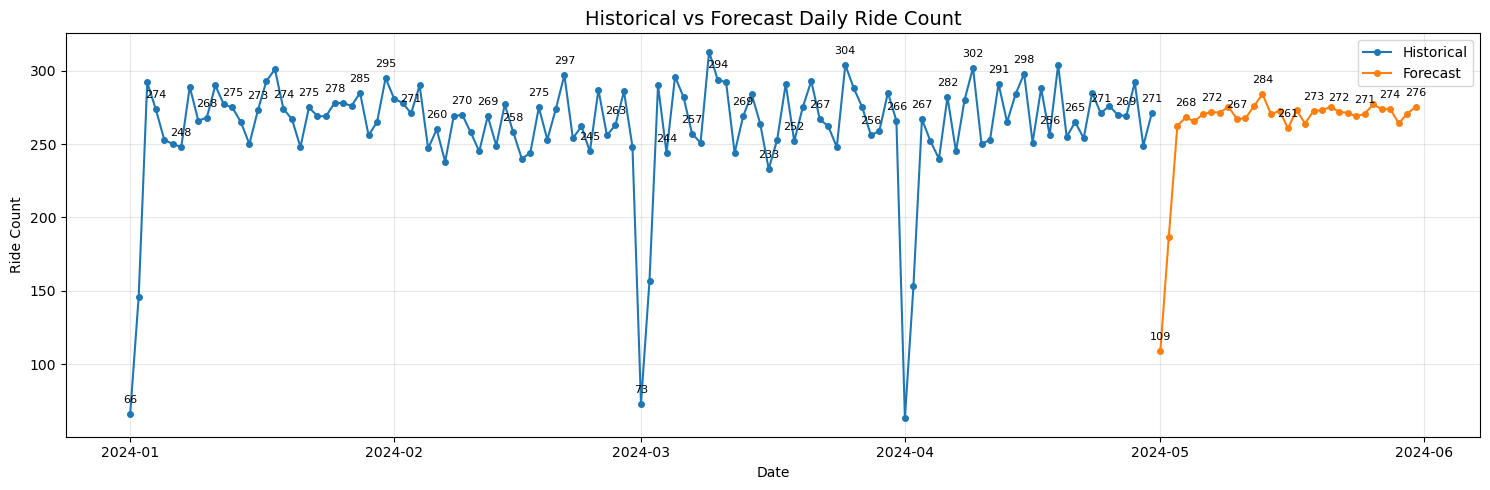

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Historical Data
plt.plot(
    daily_rides["Date of Journey"],
    daily_rides["Ride Count"],
    label="Historical",
    marker="o",
    markersize=4
)

# Forecast Data
plt.plot(
    future_rides["Date"],
    future_rides["Forecast Ride Count"],
    label="Forecast",
    marker="o",
    markersize=4
)

# كتابة القيم كل 3 نقاط للبيانات التاريخية
for i in range(0, len(daily_rides), 3):
    plt.annotate(
        f"{daily_rides['Ride Count'].iloc[i]:,.0f}",
        (
            daily_rides["Date of Journey"].iloc[i],
            daily_rides["Ride Count"].iloc[i]
        ),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

# كتابة القيم كل 3 نقاط للتوقعات
for i in range(0, len(future_rides), 3):
    plt.annotate(
        f"{future_rides['Forecast Ride Count'].iloc[i]:,.0f}",
        (
            future_rides["Date"].iloc[i],
            future_rides["Forecast Ride Count"].iloc[i]
        ),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

# عنوان ومحاور
plt.title("Historical vs Forecast Daily Ride Count", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Ride Count")

# شبكة
plt.grid(True, alpha=0.3)

# الليجند
plt.legend()

plt.tight_layout()
plt.show()

## Monthly Ride Comparison

In [104]:
# Historical Monthly Rides
df["Date of Journey"] = pd.to_datetime(df["Date of Journey"])
monthly_rides = (
    df.groupby(df["Date of Journey"].dt.month_name())["Transaction ID"]
      .count()
      .reset_index(name="Actual Rides")
)

month_order = ["January","February","March","April"]

monthly_rides["Month"] = month_order
monthly_rides = monthly_rides[["Month","Actual Rides"]]

# Forecast May
forecast_may = pd.DataFrame({
    "Month":["May"],
    "Actual Rides":[round(future_rides["Forecast Ride Count"].sum())]
})

monthly_rides = pd.concat(
    [monthly_rides,forecast_may],
    ignore_index=True
)

monthly_rides

,Month,Actual Rides
0,January,7781
1,February,7644
2,March,8111
3,April,8117
4,May,8156


## Daily Revenue Forecast

In [71]:
daily_revenue = (
    df.groupby("Date of Journey")["Price"]
      .sum()
      .reset_index()
)

daily_revenue["Date of Journey"] = pd.to_datetime(
    daily_revenue["Date of Journey"]
)

daily_revenue["Year"] = daily_revenue["Date of Journey"].dt.year
daily_revenue["Month"] = daily_revenue["Date of Journey"].dt.month
daily_revenue["Day"] = daily_revenue["Date of Journey"].dt.day
daily_revenue["DayOfWeek"] = daily_revenue["Date of Journey"].dt.dayofweek

In [72]:
X = daily_revenue[
    ["Year","Month","Day","DayOfWeek"]
]

y = daily_revenue["Price"]

revenue_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

revenue_model.fit(X,y)

pred = revenue_model.predict(X)

print("MAE :",mean_absolute_error(y,pred))
print("RMSE :",np.sqrt(mean_squared_error(y,pred)))
print("R2 :",r2_score(y,pred))

MAE : 230.1920247933885
RMSE : 336.4908298275866
R2 : 0.9109417914034089


In [73]:
future_revenue = future_rides.copy()

future_revenue["Forecast Revenue"] = revenue_model.predict(
    future_revenue[
        ["Year","Month","Day","DayOfWeek"]
    ]
)

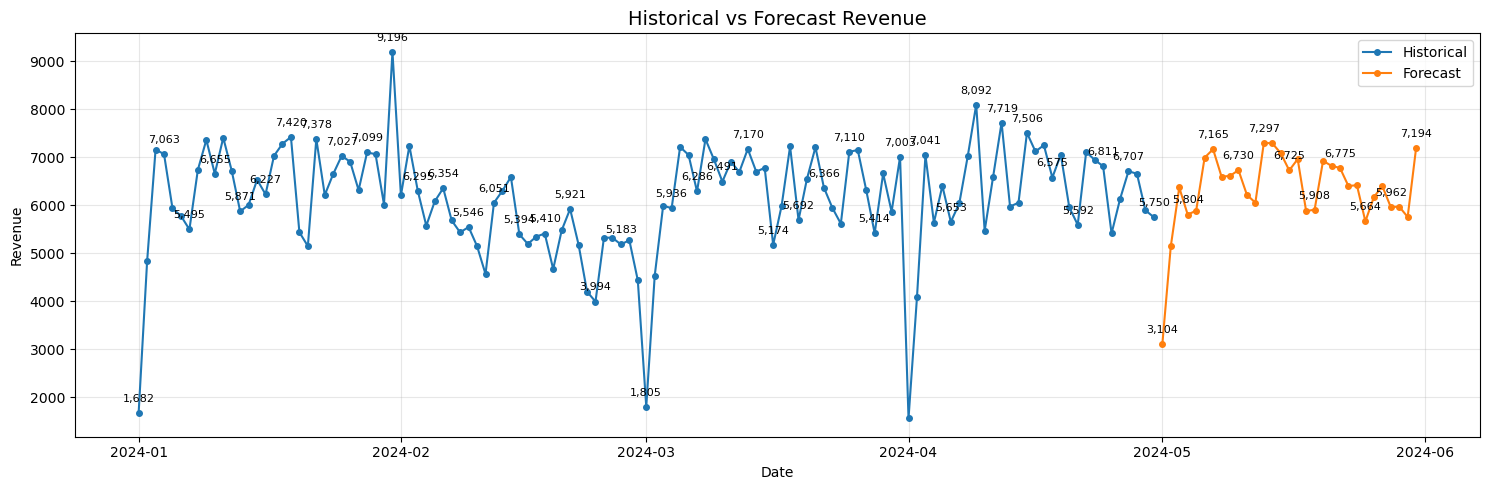

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Historical Revenue
plt.plot(
    daily_revenue["Date of Journey"],
    daily_revenue["Price"],
    label="Historical",
    marker="o",
    markersize=4
)

plt.plot(
    future_revenue["Date"],
    future_revenue["Forecast Revenue"],
    label="Forecast",
    marker="o",
    markersize=4
)

for i in range(0, len(daily_revenue), 3):
    plt.annotate(
        f"{daily_revenue['Price'].iloc[i]:,.0f}",
        (
            daily_revenue["Date of Journey"].iloc[i],
            daily_revenue["Price"].iloc[i]
        ),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

for i in range(0, len(future_revenue), 3):
    plt.annotate(
        f"{future_revenue['Forecast Revenue'].iloc[i]:,.0f}",
        (
            future_revenue["Date"].iloc[i],
            future_revenue["Forecast Revenue"].iloc[i]
        ),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

# العنوان والمحاور
plt.title("Historical vs Forecast Revenue", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Revenue")

# الشبكة
plt.grid(True, alpha=0.3)

# الليجند
plt.legend()

plt.tight_layout()
plt.show()

##  Monthly Revenue Comparison

In [103]:
monthly_revenue = (
    df.groupby(df["Date of Journey"].dt.month_name())["Price"]
      .sum()
      .reset_index(name="Actual Revenue")
)

monthly_revenue["Month"] = month_order
monthly_revenue = monthly_revenue[
    ["Month","Actual Revenue"]
]

forecast_rev = pd.DataFrame({
    "Month":["May"],
    "Actual Revenue":[round(future_revenue["Forecast Revenue"].sum(),2)]
})

monthly_revenue = pd.concat(
    [monthly_revenue,forecast_rev],
    ignore_index=True
)

monthly_revenue

,Month,Actual Revenue
0,January,187782.00
1,February,159374.00
2,March,199618.00
3,April,195147.00
4,May,196241.66


## Ticket Class Demand

In [97]:
df["Date of Journey"] = pd.to_datetime(df["Date of Journey"])

def forecast_ticket_demand(category_col):

    month_order = ["January","February","March","April"]

    result = []

    for category in df[category_col].unique():

        # Daily demand for each category
        temp = (
            df[df[category_col] == category]
            .groupby("Date of Journey")
            .size()
            .reset_index(name="Demand")
        )

        temp["Year"] = temp["Date of Journey"].dt.year
        temp["Month"] = temp["Date of Journey"].dt.month
        temp["Day"] = temp["Date of Journey"].dt.day
        temp["DayOfWeek"] = temp["Date of Journey"].dt.dayofweek

        X = temp[["Year","Month","Day","DayOfWeek"]]
        y = temp["Demand"]

        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )

        model.fit(X, y)

        # Forecast May
        future = pd.date_range("2024-05-01","2024-05-31")

        future_df = pd.DataFrame({
            "Date":future
        })

        future_df["Year"] = future_df["Date"].dt.year
        future_df["Month"] = future_df["Date"].dt.month
        future_df["Day"] = future_df["Date"].dt.day
        future_df["DayOfWeek"] = future_df["Date"].dt.dayofweek

        future_df["Forecast"] = model.predict(
            future_df[
                ["Year","Month","Day","DayOfWeek"]
            ]
        )

        may_forecast = round(future_df["Forecast"].sum())

        # Actual Jan-Apr
        actual = (
            df[df[category_col] == category]
            .groupby(df["Date of Journey"].dt.month_name())
            .size()
            .reindex(month_order)
        )

        actual.loc["May"] = may_forecast

        result.append(actual)

    result = pd.DataFrame(result).T

    result.columns = df[category_col].unique()

    return result

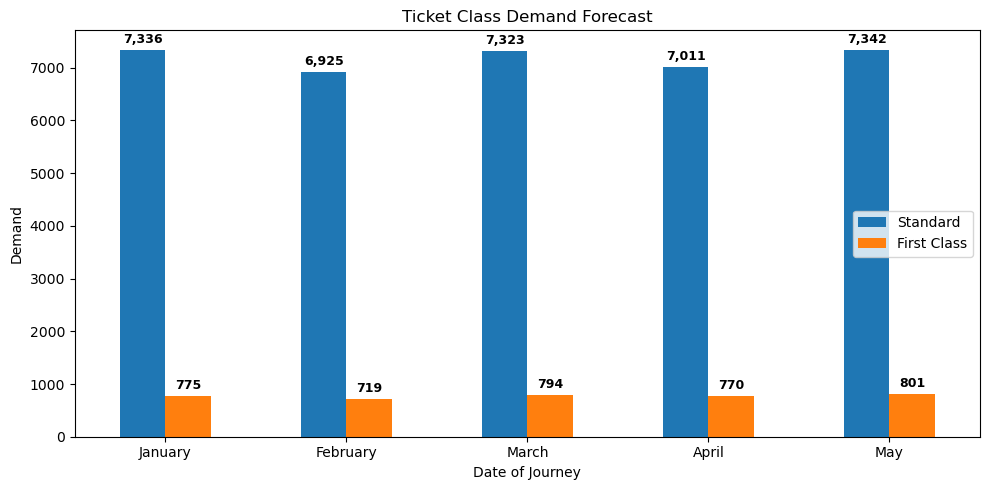

In [101]:
ax = ticket_class_forecast.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Ticket Class Demand Forecast")
plt.ylabel("Demand")
plt.xticks(rotation=0)

for container in ax.containers:
    labels = [f"{int(v):,}" if not np.isnan(v) else "" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [98]:
ticket_class_forecast = forecast_ticket_demand("Ticket Class")

ticket_class_forecast

,Standard,First Class
Date of Journey,,
January,7336,775
February,6925,719
March,7323,794
April,7011,770
May,7342,801


## Ticket Type Demand

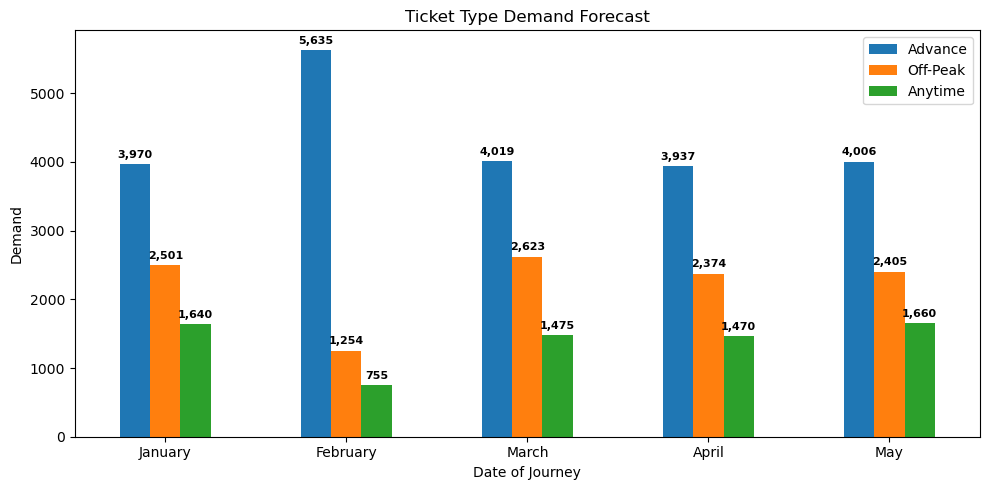

In [102]:
ax = ticket_type_forecast.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Ticket Type Demand Forecast")
plt.ylabel("Demand")
plt.xticks(rotation=0)

# إضافة القيم فوق كل عمود
for container in ax.containers:
    labels = [f"{int(v):,}" if not np.isnan(v) else "" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=8,      # صغرته شوية لأن الأعمدة أكتر
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [99]:
ticket_type_forecast = forecast_ticket_demand("Ticket Type")

ticket_type_forecast

,Advance,Off-Peak,Anytime
Date of Journey,,,
January,3970,2501,1640
February,5635,1254,755
March,4019,2623,1475
April,3937,2374,1470
May,4006,2405,1660


## Forecast Delay Reasons

In [105]:
df["Date of Journey"] = pd.to_datetime(df["Date of Journey"])

def forecast_delay_reason():

    month_order = ["January","February","March","April"]

    result = []

    delay_reasons = df["Reason for Delay"].dropna().unique()

    for reason in delay_reasons:

        temp = (
            df[df["Reason for Delay"] == reason]
            .groupby("Date of Journey")
            .size()
            .reset_index(name="Count")
        )

        if len(temp) < 5:
            continue

        temp["Year"] = temp["Date of Journey"].dt.year
        temp["Month"] = temp["Date of Journey"].dt.month
        temp["Day"] = temp["Date of Journey"].dt.day
        temp["DayOfWeek"] = temp["Date of Journey"].dt.dayofweek

        X = temp[["Year","Month","Day","DayOfWeek"]]
        y = temp["Count"]

        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )

        model.fit(X, y)

        future = pd.date_range("2024-05-01","2024-05-31")

        future_df = pd.DataFrame({
            "Date":future
        })

        future_df["Year"] = future_df["Date"].dt.year
        future_df["Month"] = future_df["Date"].dt.month
        future_df["Day"] = future_df["Date"].dt.day
        future_df["DayOfWeek"] = future_df["Date"].dt.dayofweek

        future_df["Forecast"] = model.predict(
            future_df[
                ["Year","Month","Day","DayOfWeek"]
            ]
        )

        may_forecast = round(future_df["Forecast"].sum())

        actual = (
            df[df["Reason for Delay"] == reason]
            .groupby(df["Date of Journey"].dt.month_name())
            .size()
            .reindex(month_order)
        )

        actual.loc["May"] = may_forecast

        result.append(actual)

    result = pd.DataFrame(result).T

    result.columns = delay_reasons[:len(result.columns)]

    return result

In [106]:
delay_reason_forecast = forecast_delay_reason()

delay_reason_forecast

,No Delay,Signal Failure,Technical Issue,Weather,Staff Shortage,Traffic
Date of Journey,,,,,,
January,7077,227,164,337,243,63
February,6651,192,171,378,177,75
March,6980,289,211,328,215,94
April,6773,262,161,329,174,82
May,7092,276,190,368,191,121


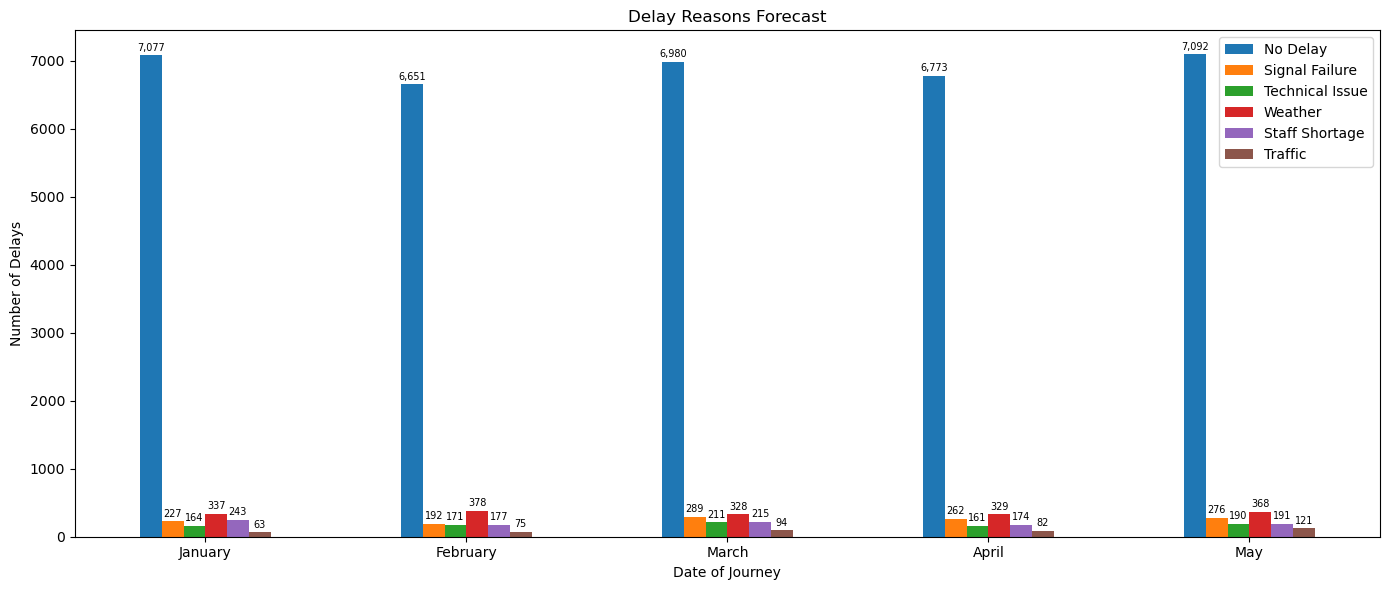

In [108]:
ax = delay_reason_forecast.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Delay Reasons Forecast")
plt.ylabel("Number of Delays")
plt.xticks(rotation=0)

for container in ax.containers:
    labels = [
        f"{int(v):,}" if not np.isnan(v) else ""
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=2,
        fontsize=7
    )

plt.tight_layout()
plt.show()